# “House Price Prediction Using Linear Regression”

* Question 1 Can housing features accurately predict property sale prices?

* Question 2 Which housing characteristics most strongly influence home prices?

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [9]:
housing=pd.read_csv("AmesHousing.csv")
housing 

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,NaN,8885,Pave,NaN,IR1,Low,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


In [10]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [11]:
housing.isna().sum()

Order               0
PID                 0
MS SubClass         0
MS Zoning           0
Lot Frontage      490
                 ... 
Mo Sold             0
Yr Sold             0
Sale Type           0
Sale Condition      0
SalePrice           0
Length: 82, dtype: int64

In [12]:
housing.isnull().sum().sort_values(ascending=False).head(10)

Pool QC          2917
Misc Feature     2824
Alley            2732
Fence            2358
Mas Vnr Type     1775
Fireplace Qu     1422
Lot Frontage      490
Garage Cond       159
Garage Finish     159
Garage Yr Blt     159
dtype: int64

In [13]:
housing.dropna(subset=['SalePrice'],inplace=True)

## EDA

## Sale Price Distribution

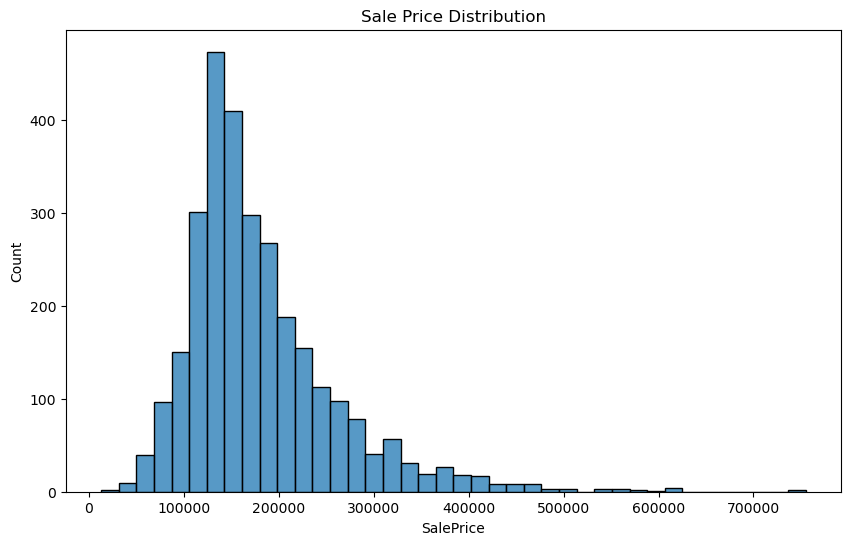

In [14]:
plt.figure(figsize=(10,6))
sns.histplot(housing['SalePrice'], bins=40)
plt.title('Sale Price Distribution')
plt.show()

## Living Area vs Sale Price

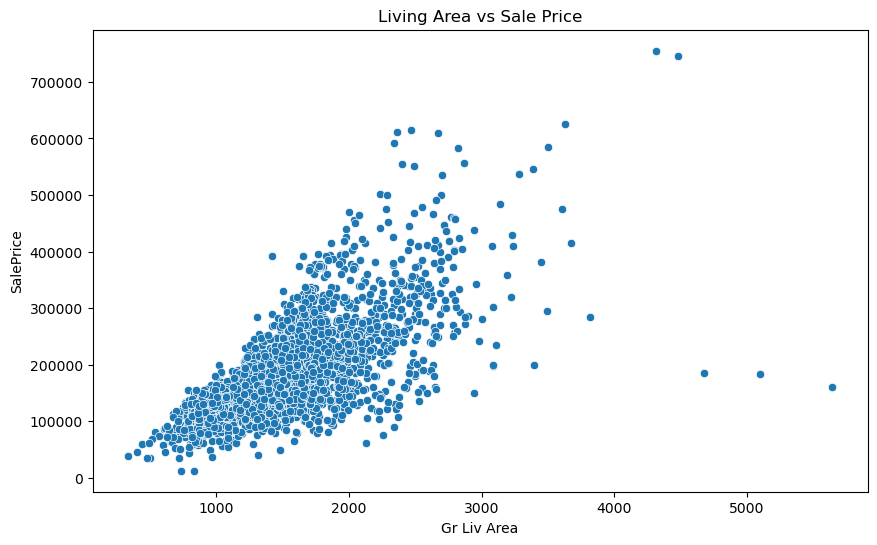

In [16]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='Gr Liv Area',
    y='SalePrice',
    data=housing
)
plt.title('Living Area vs Sale Price')
plt.show()

## Overall Quality vs Sale Price

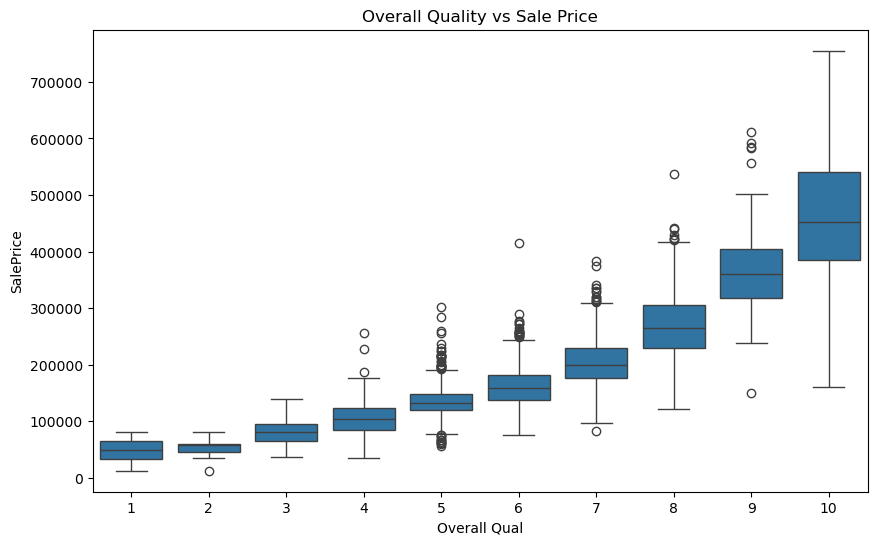

In [17]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='Overall Qual',
    y='SalePrice',
    data=housing
)

plt.title('Overall Quality vs Sale Price')

plt.show()

## Neighbourhood Analysis

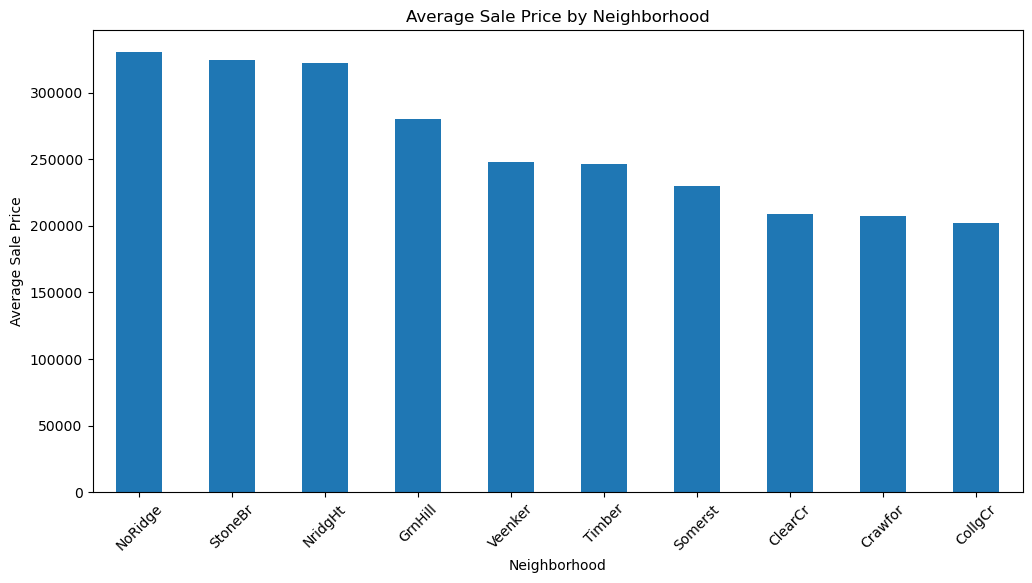

In [18]:
top_neighborhoods = housing.groupby(
    'Neighborhood'
)['SalePrice'].mean().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12,6))
top_neighborhoods.plot(kind='bar')
plt.title('Average Sale Price by Neighborhood')
plt.ylabel('Average Sale Price')
plt.xticks(rotation=45)
plt.show()

## Correlation

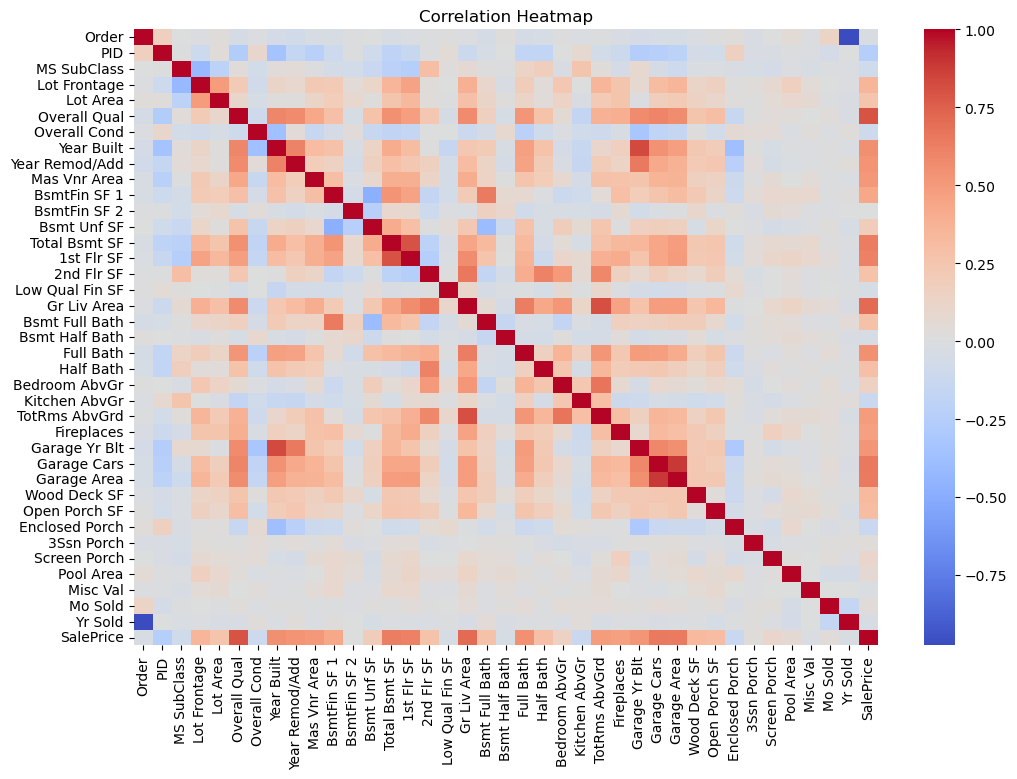

In [21]:
plt.figure(figsize=(12,8))

correlation = housing.corr(
    numeric_only=True
)

sns.heatmap(
    correlation,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

## Feature Selection

In [22]:
X = housing[[
    'Overall Qual',
    'Gr Liv Area',
    'Garage Cars',
    'Total Bsmt SF',
    'Year Built'
]]

y = housing['SalePrice']

In [23]:
X = X.fillna(X.median())

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.30,random_state=42)

In [25]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
predictions = model.predict(X_test)

## MAE, MSE ,R-square score

In [27]:
print(mean_absolute_error(y_test,predictions))

24422.37641420548


In [28]:
print(mean_squared_error( y_test,predictions))

1393723368.9381952


In [29]:
print(r2_score(y_test,predictions))

0.8017301856464628


## Actual vs Predicted Prices

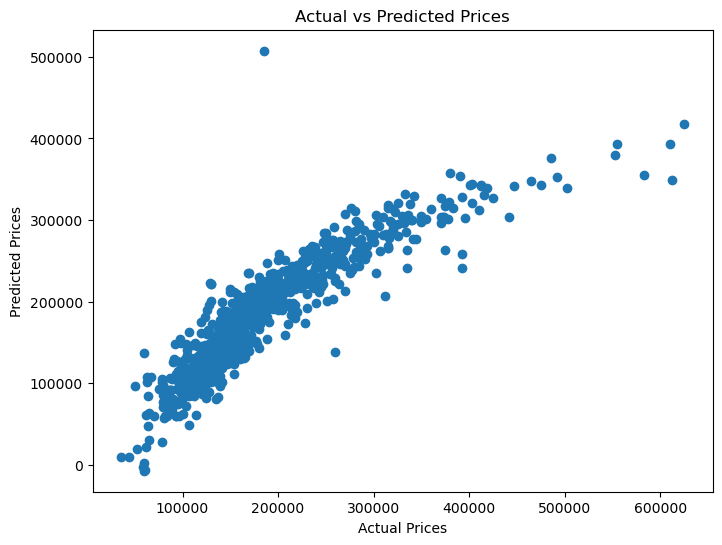

In [30]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    predictions
)

plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')

plt.title('Actual vs Predicted Prices')

plt.show()

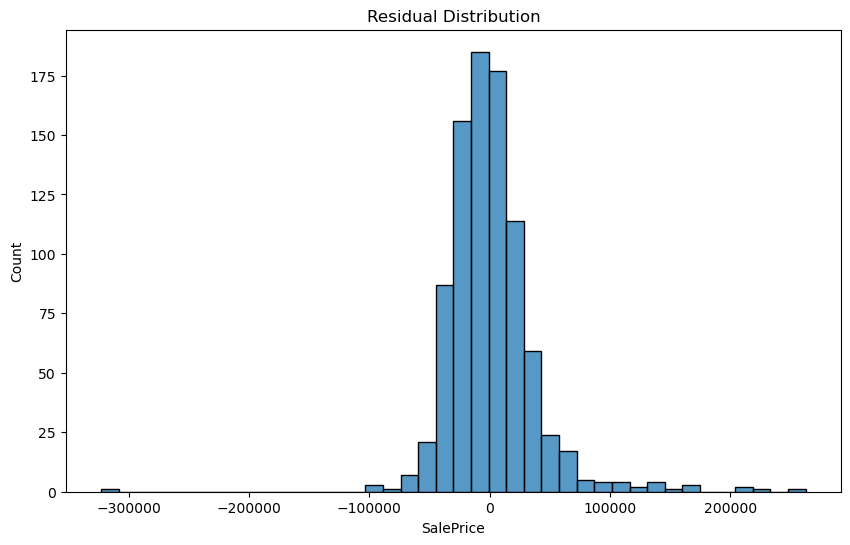

In [31]:
plt.figure(figsize=(10,6))

sns.histplot(
    y_test - predictions,
    bins=40
)

plt.title('Residual Distribution')

plt.show()

## Final Business Insights
* Larger homes generally command higher prices.
* Construction quality is one of the strongest price drivers.
* Neighborhood location significantly impacts valuation.
* Garage capacity and basement size positively affect pricing.
* Linear regression successfully predicts housing prices using structural property features.